# SYSTEM DESIGN INTEGRATED MINING FUEL RATIO (FR) & CAPACITY MANAGEMENT
## Menerapkan Dataset Excel `UPDATE_Fuel ratio calculation 2026 dummy data.xlsx`

Notebook ini dirancang dengan alur sistem lengkap sebagai berikut:
1. **Extraction & Baseline Calculation:** Membaca data Excel dan menghitung baseline Fuel Ratio (FR) per aktivitas (Loading, Hauling, Supporting, Dewatering).
2. **Time Series Deret Waktu & Data Cuaca (Scraping/API):** Menggabungkan data historis cuaca riil dari Open-Meteo API dengan deret waktu penggunaan BBM & BCM harian.
3. **XGBoost Forecasting & Dynamic Thresholds:** Forecasting FR Harian dan menentukan Warning Threshold (+8%) & Critical Threshold (+18%).
4. **Neural Network Anomaly Detection:** Pendeteksian lonjakan (spikes) penggunaan BBM per unit menggunakan Autoencoder PyTorch.
5. **Combined Capacity Determination:** Penggabungan XGBoost & Neural Network untuk menentukan alokasi kapasitas BBM & unit aktif per aktivitas.

In [1]:
# Install dependencies yang dibutuhkan
!pip install xgboost torch requests pandas numpy matplotlib seaborn scikit-learn openpyxl

In [2]:
import requests
import json
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Set Style & Random Seed
sns.set_theme(style="whitegrid")
np.random.seed(42)
torch.manual_seed(42)

print("=== INISIALISASI SISTEM DESIGN FUEL RATIO & KAPASITAS TAMBANG ===")

=== INISIALISASI SISTEM DESIGN FUEL RATIO & KAPASITAS TAMBANG ===


In [3]:
# ==============================================================================
# MODUL 1: EXTRACT BASELINE DATASET & CALCULATION PER ACTIVITY
# ==============================================================================

# Dataset Baseline Unit dari Excel Anda
unit_excel_data = [
    # LOADING UNITS
    {"Unit": "EX2600-6",   "Activity": "LOADING",    "Qty": 3,  "FC_Lhr": 187.0, "Prod_BCMhr": 920.0},
    {"Unit": "PC1250-11R", "Activity": "LOADING",    "Qty": 18, "FC_Lhr": 59.0,  "Prod_BCMhr": 310.0},
    {"Unit": "PC1250SP8",  "Activity": "LOADING",    "Qty": 12, "FC_Lhr": 64.0,  "Prod_BCMhr": 320.0},
    {"Unit": "PC2000-11R", "Activity": "LOADING",    "Qty": 18, "FC_Lhr": 100.0, "Prod_BCMhr": 820.0},
    {"Unit": "PC2000-8",   "Activity": "LOADING",    "Qty": 16, "FC_Lhr": 100.0, "Prod_BCMhr": 480.0},
    {"Unit": "PC3400",     "Activity": "LOADING",    "Qty": 2,  "FC_Lhr": 12.0,   "Prod_BCMhr": 940.0},
    {"Unit": "PC3400EX11", "Activity": "LOADING",    "Qty": 1,  "FC_Lhr": 21.0,   "Prod_BCMhr": 1160.0},

    # HAULING UNITS (3900M DISTANCE)
    {"Unit": "HD785-7",    "Activity": "HAULING",    "Qty": 400,"FC_Lhr": 77.0,  "Prod_BCMhr": 109.565217},
    {"Unit": "HD785-8",    "Activity": "HAULING",    "Qty": 15, "FC_Lhr": 77.0,  "Prod_BCMhr": 109.565217},

    # SUPPORTING UNITS
    {"Unit": "CAT14M3",     "Activity": "SUPPORTING", "Qty": 3,  "FC_Lhr": 16.0,  "Prod_BCMhr": None},
    {"Unit": "D155-6",      "Activity": "SUPPORTING", "Qty": 8,  "FC_Lhr": 29.0,  "Prod_BCMhr": None},
    {"Unit": "D155A6A",     "Activity": "SUPPORTING", "Qty": 4,  "FC_Lhr": 29.0,  "Prod_BCMhr": None},
    {"Unit": "D155A6R",     "Activity": "SUPPORTING", "Qty": 36, "FC_Lhr": 29.0,  "Prod_BCMhr": None},
    {"Unit": "D375-6",      "Activity": "SUPPORTING", "Qty": 10, "FC_Lhr": 67.0,  "Prod_BCMhr": None},
    {"Unit": "D375A6R",     "Activity": "SUPPORTING", "Qty": 20, "FC_Lhr": 67.0,  "Prod_BCMhr": None},
    {"Unit": "GD825A2",     "Activity": "SUPPORTING", "Qty": 49, "FC_Lhr": 29.0,  "Prod_BCMhr": None},
    {"Unit": "FMX440FT",    "Activity": "SUPPORTING", "Qty": 20, "FC_Lhr": 44.0,  "Prod_BCMhr": None},
    {"Unit": "FMX440WT",    "Activity": "SUPPORTING", "Qty": 2,  "FC_Lhr": 23.0,  "Prod_BCMhr": None},
    {"Unit": "HD7857WT",    "Activity": "SUPPORTING", "Qty": 22, "FC_Lhr": 77.0,  "Prod_BCMhr": None},
    {"Unit": "P360CB6X6WT", "Activity": "SUPPORTING", "Qty": 6,  "FC_Lhr": 26.0,  "Prod_BCMhr": None},
    {"Unit": "P360CB6X6",   "Activity": "SUPPORTING", "Qty": 3,  "FC_Lhr": 26.0,  "Prod_BCMhr": None},

    # DEWATERING UNITS
    {"Unit": "DNDLSA6X8",   "Activity": "DEWATERING", "Qty": 6,  "FC_Lhr": 40.0,  "Prod_BCMhr": None},
    {"Unit": "DREDGERPUMP", "Activity": "DEWATERING", "Qty": 7,  "FC_Lhr": 75.0,  "Prod_BCMhr": None},
    {"Unit": "DRHY85160B",  "Activity": "DEWATERING", "Qty": 9,  "FC_Lhr": 45.0,  "Prod_BCMhr": None},
    {"Unit": "EGS380-6",    "Activity": "DEWATERING", "Qty": 3,  "FC_Lhr": 10.0,  "Prod_BCMhr": None},
    {"Unit": "EWP420",      "Activity": "DEWATERING", "Qty": 40, "FC_Lhr": 40.0,  "Prod_BCMhr": None},
    {"Unit": "KSB",         "Activity": "DEWATERING", "Qty": 6,  "FC_Lhr": 25.0,  "Prod_BCMhr": None},
    {"Unit": "MEB420EXHV",  "Activity": "DEWATERING", "Qty": 30, "FC_Lhr": 45.0,  "Prod_BCMhr": None},
    {"Unit": "MF420E",      "Activity": "DEWATERING", "Qty": 12, "FC_Lhr": 45.0,  "Prod_BCMhr": None},
    {"Unit": "MF420EX",     "Activity": "DEWATERING", "Qty": 6,  "FC_Lhr": 45.0,  "Prod_BCMhr": None},
    {"Unit": "MF420EXHV",   "Activity": "DEWATERING", "Qty": 20, "FC_Lhr": 45.0,  "Prod_BCMhr": None},
    {"Unit": "MFV290",      "Activity": "DEWATERING", "Qty": 2,  "FC_Lhr": 45.0,  "Prod_BCMhr": None},
    {"Unit": "MFV290C",     "Activity": "DEWATERING", "Qty": 4,  "FC_Lhr": 45.0,  "Prod_BCMhr": None},
    {"Unit": "MFV420EXHV",  "Activity": "DEWATERING", "Qty": 20, "FC_Lhr": 45.0,  "Prod_BCMhr": None},
    {"Unit": "RF85MW",      "Activity": "DEWATERING", "Qty": 10, "FC_Lhr": 50.0,  "Prod_BCMhr": None},
]

df_units = pd.DataFrame(unit_excel_data)
TOTAL_PROD_TAMBANG_BCM = 91_276_500

# Perhitungan Baseline Fuel Ratio per Aktivitas
loading_fc = (df_units[df_units['Activity']=='LOADING']['Qty'] * df_units[df_units['Activity']=='LOADING']['FC_Lhr']).sum()
loading_prod = (df_units[df_units['Activity']=='LOADING']['Qty'] * df_units[df_units['Activity']=='LOADING']['Prod_BCMhr']).sum()
BASE_LOADING_FR = loading_fc / loading_prod

hauling_fc = (df_units[df_units['Activity']=='HAULING']['Qty'] * df_units[df_units['Activity']=='HAULING']['FC_Lhr']).sum()
hauling_prod = (df_units[df_units['Activity']=='HAULING']['Qty'] * df_units[df_units['Activity']=='HAULING']['Prod_BCMhr']).sum()
BASE_HAULING_FR = hauling_fc / hauling_prod

BASE_SUPPORTING_FR = 0.2199
BASE_DEWATERING_FR = 0.0800
BASE_TOTAL_FR = BASE_LOADING_FR + BASE_HAULING_FR + BASE_SUPPORTING_FR + BASE_DEWATERING_FR

print("=== SUMMARY BASELINE FUEL RATIO PER ACTIVITY ===")
print(f"1. Loading FR    : {BASE_LOADING_FR:.4f} L/BCM")
print(f"2. Hauling FR    : {BASE_HAULING_FR:.4f} L/BCM")
print(f"3. Supporting FR : {BASE_SUPPORTING_FR:.4f} L/BCM")
print(f"4. Dewatering FR : {BASE_DEWATERING_FR:.4f} L/BCM")
print(f"TOTAL BASELINE FR: {BASE_TOTAL_FR:.4f} L/BCM\n")

=== SUMMARY BASELINE FUEL RATIO PER ACTIVITY ===
1. Loading FR    : 0.1550 L/BCM
2. Hauling FR    : 0.7028 L/BCM
3. Supporting FR : 0.2199 L/BCM
4. Dewatering FR : 0.0800 L/BCM
TOTAL BASELINE FR: 1.1576 L/BCM



In [4]:
# ==============================================================================
# MODUL 2: WEATHER SCRAPING (API) & TIME SERIES DERET WAKTU SINTETIS
# ==============================================================================

LATITUDE = -0.13   # Area Tambang Bontang / East Kalimantan
LONGITUDE = 117.45
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=365)

weather_url = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={LATITUDE}&longitude={LONGITUDE}&"
    f"start_date={start_date}&end_date={end_date}&"
    f"daily=rain_sum,temperature_2m_max,wind_speed_10m_max&"
    f"timezone=Asia%2FMakassar"
)

try:
    response = requests.get(weather_url)
    data = response.json()
    df_weather = pd.DataFrame({
        'Date': pd.to_datetime(data['daily']['time']),
        'Curah_Hujan_mm': data['daily']['rain_sum'],
        'Temp_Max_C': data['daily']['temperature_2m_max'],
        'Kecepatan_Angin_kmh': data['daily']['wind_speed_10m_max']
    })
    print(" [OK] Data cuaca berhasil di-fetch dari Open-Meteo API.")
except Exception as e:
    dates = pd.date_range(start=start_date, end=end_date)
    df_weather = pd.DataFrame({
        'Date': dates,
        'Curah_Hujan_mm': np.random.exponential(scale=10, size=len(dates)),
        'Temp_Max_C': np.random.normal(loc=31, scale=2, size=len(dates)),
        'Kecepatan_Angin_kmh': np.random.normal(loc=12, scale=3, size=len(dates))
    })

df_weather['Curah_Hujan_mm'] = df_weather['Curah_Hujan_mm'].fillna(0)
BASE_TARGET_PROD_DAILY = TOTAL_PROD_TAMBANG_BCM / 365

# Generasi Time Series Deret Waktu Harian
ts_daily = []
for idx, row in df_weather.iterrows():
    rain = row['Curah_Hujan_mm']
    haul_distance = 3900 + np.random.normal(0, 100) + (rain * 8)
    prod_factor = max(0.5, 1.0 - (min(rain, 50) * 0.008) + np.random.normal(0, 0.02))
    daily_prod_bcm = BASE_TARGET_PROD_DAILY * prod_factor

    load_fr_d = BASE_LOADING_FR * (1 + (1 - prod_factor)*0.2)
    haul_fr_d = BASE_HAULING_FR * (haul_distance / 3900) * (1 + (1 - prod_factor)*0.3)
    supp_fr_d = BASE_SUPPORTING_FR * (1 + (rain * 0.015))
    dew_fr_d = BASE_DEWATERING_FR * (1 + (rain * 0.045))
    tot_fr_d = load_fr_d + haul_fr_d + supp_fr_d + dew_fr_d

    ts_daily.append({
        'Date': row['Date'], 'Curah_Hujan_mm': rain, 'Temp_Max_C': row['Temp_Max_C'],
        'Haul_Distance_m': haul_distance, 'Daily_Prod_BCM': daily_prod_bcm,
        'Loading_FR': load_fr_d, 'Hauling_FR': haul_fr_d, 'Supporting_FR': supp_fr_d, 'Dewatering_FR': dew_fr_d,
        'Actual_FR_L_BCM': tot_fr_d
    })

df_ts_daily = pd.DataFrame(ts_daily)
df_ts_daily['DayOfWeek'] = df_ts_daily['Date'].dt.dayofweek
df_ts_daily['Rain_Lag1'] = df_ts_daily['Curah_Hujan_mm'].shift(1).fillna(0)
df_ts_daily['FR_Lag1'] = df_ts_daily['Actual_FR_L_BCM'].shift(1).bfill()
df_ts_daily['FR_Lag2'] = df_ts_daily['Actual_FR_L_BCM'].shift(2).bfill()

print(" [OK] Time Series harian berhasil dibentuk (365 Hari).")

 [OK] Data cuaca berhasil di-fetch dari Open-Meteo API.
 [OK] Time Series harian berhasil dibentuk (365 Hari).


In [5]:
# ==============================================================================
# MODUL 3: XGBOOST FORECASTING & DYNAMIC THRESHOLDS
# ==============================================================================

features = ['Curah_Hujan_mm', 'Temp_Max_C', 'Haul_Distance_m', 'Daily_Prod_BCM', 'DayOfWeek', 'Rain_Lag1', 'FR_Lag1', 'FR_Lag2']
X = df_ts_daily[features].values
y = df_ts_daily['Actual_FR_L_BCM'].values

train_size = int(len(df_ts_daily) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Training XGBoost Regressor
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Dynamic Thresholds
WARNING_THRESHOLD = BASE_TOTAL_FR * 1.08  # +8% dari Budget Baseline
CRITICAL_THRESHOLD = BASE_TOTAL_FR * 1.18 # +18% dari Budget Baseline

# Evaluasi Status
df_test_eval = df_ts_daily.iloc[train_size:].copy()
df_test_eval['Forecast_FR_XGB'] = y_pred_xgb
df_test_eval['Status'] = df_test_eval['Forecast_FR_XGB'].apply(
    lambda x: 'CRITICAL' if x >= CRITICAL_THRESHOLD else ('WARNING' if x >= WARNING_THRESHOLD else 'NORMAL')
)

print(f"=== EVALUASI XGBOOST FORECASTING ===")
print(f"R2 Score: {r2_score(y_test, y_pred_xgb):.4f} | MAE: {mean_absolute_error(y_test, y_pred_xgb):.4f}")
print(f"Warning Threshold : {WARNING_THRESHOLD:.4f} L/BCM")
print(f"Critical Threshold: {CRITICAL_THRESHOLD:.4f} L/BCM")
print("Distribusi Status Prediksi:")
print(df_test_eval['Status'].value_counts())

=== EVALUASI XGBOOST FORECASTING ===
R2 Score: 0.9901 | MAE: 0.0045
Warning Threshold : 1.2503 L/BCM
Critical Threshold: 1.3660 L/BCM
Distribusi Status Prediksi:
Status
NORMAL      57
WARNING     15
CRITICAL     2
Name: count, dtype: int64


In [6]:
# ==============================================================================
# MODUL 4: NEURAL NETWORK ANOMALY DETECTION (PER ACTIVITY & PER UNIT)
# ==============================================================================

# Generasi Data Penggunaan Harian Per Unit
ts_unit_records = []
for d in df_ts_daily['Date'].values:
    rain = df_ts_daily.loc[df_ts_daily['Date'] == d, 'Curah_Hujan_mm'].values[0]
    for idx, row in df_units.iterrows():
        unit_name = row['Unit']
        act_type = row['Activity']
        qty = row['Qty']
        fc_base = row['FC_Lhr']

        fc_actual = fc_base * (1 + np.random.normal(0, 0.05) + (rain * 0.002))
        # Injeksi Anomali Lonjakan (Spike) Acak (~3.5% Peluang)
        is_spike = np.random.rand() < 0.035
        if is_spike: fc_actual *= np.random.uniform(1.45, 2.1) # Spike Pembengkakan BBM

        unit_fuel_day = qty * 20 * fc_actual
        unit_fr = unit_fuel_day / (BASE_TARGET_PROD_DAILY / len(df_units))

        ts_unit_records.append({
            'Date': d, 'Unit': unit_name, 'Activity': act_type, 'Qty': qty,
            'FC_Actual': fc_actual, 'Unit_Fuel_L_Day': unit_fuel_day, 'Unit_FR': unit_fr,
            'Rain_mm': rain, 'Is_Spike_GroundTruth': 1 if is_spike else 0
        })

df_unit_ts = pd.DataFrame(ts_unit_records)

# Training Autoencoder Neural Network
X_un = df_unit_ts[['FC_Actual', 'Unit_Fuel_L_Day', 'Unit_FR', 'Rain_mm']].values
scaler_ae = StandardScaler()
X_un_scaled = scaler_ae.fit_transform(X_un)
X_un_tensor = torch.tensor(X_un_scaled, dtype=torch.float32)

class AutoencoderDetector(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 8), nn.ReLU(), nn.Linear(8, 3), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(3, 8), nn.ReLU(), nn.Linear(8, input_dim))
    def forward(self, x): return self.decoder(self.encoder(x))

model_ae = AutoencoderDetector(X_un_scaled.shape[1])
optimizer_ae = torch.optim.Adam(model_ae.parameters(), lr=0.01)
criterion_ae = nn.MSELoss()

model_ae.train()
for epoch in range(35):
    optimizer_ae.zero_grad()
    loss_ae = criterion_ae(model_ae(X_un_tensor), X_un_tensor)
    loss_ae.backward()
    optimizer_ae.step()

# Evaluasi Reconstruction Error
model_ae.eval()
with torch.no_grad():
    recon_err = torch.mean((X_un_tensor - model_ae(X_un_tensor)) ** 2, dim=1).numpy()

df_unit_ts['NN_Anomaly_Spike'] = (recon_err > np.percentile(recon_err, 93.5)).astype(int)

# 1. Spike Report
spike_report = df_unit_ts.groupby(['Unit', 'Activity']).agg(
    Total_Spikes_Detected=('NN_Anomaly_Spike', 'sum'),
    Avg_FC_Normal=('FC_Actual', lambda x: x[df_unit_ts.loc[x.index, 'NN_Anomaly_Spike'] == 0].mean()),
    Avg_FC_Spike=('FC_Actual', lambda x: x[df_unit_ts.loc[x.index, 'NN_Anomaly_Spike'] == 1].mean()),
    Max_FR_Recorded=('Unit_FR', 'max')
).reset_index().sort_values(by='Total_Spikes_Detected', ascending=False)

# 2. Detail Report Per Activity
detail_act_report = df_unit_ts.groupby('Activity').agg(
    Total_Unit_Types=('Unit', 'nunique'),
    Total_Spike_Events=('NN_Anomaly_Spike', 'sum'),
    Avg_Unit_FR=('Unit_FR', 'mean'),
    Total_Fuel_Cons_L=('Unit_Fuel_L_Day', 'sum')
).reset_index()

print("=========================================================================================")
print("                                 1. SPIKE REPORT PER UNIT                                ")
print("=========================================================================================")
print(spike_report.head(10).to_string(index=False))
print("\n=========================================================================================")
print("                            2. DETAIL REPORT PER ACTIVITY                                ")
print("=========================================================================================")
print(detail_act_report.to_string(index=False))

                                 1. SPIKE REPORT PER UNIT                                
      Unit   Activity  Total_Spikes_Detected  Avg_FC_Normal  Avg_FC_Spike  Max_FR_Recorded
   HD785-7    HAULING                    366            NaN     80.788030       182.242465
  EX2600-6    LOADING                    366            NaN    192.281724         3.175688
  EGS380-6 DEWATERING                      9      10.288654     10.696480         0.184194
PC2000-11R    LOADING                      9     102.552036    185.527249        10.661756
  PC2000-8    LOADING                      8     101.809356    180.751484         9.212620
    PC3400    LOADING                      7      12.470978     12.891682         0.137613
   CAT14M3 SUPPORTING                      6      16.583989     16.935849         0.306005
PC3400EX11    LOADING                      4      22.101060     22.289941         0.121518
   HD785-8    HAULING                      4      79.820571    149.278832         6.803220


In [8]:
import requests
import json
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Set Style & Random Seed
sns.set_theme(style="whitegrid")
np.random.seed(42)
torch.manual_seed(42)

print("=== INISIALISASI SISTEM DESIGN FUEL RATIO & KAPASITAS TAMBANG ===")
# ==============================================================================
# MODUL 5: COMBINED CAPACITY DETERMINATION (XGBOOST + NEURAL NETWORK)
# ==============================================================================

# Kombinasi Prediksi Forecast (XGBoost) & Bobot Penyesuaian Anomali (Neural Network)
last_fc_row = df_test_eval.iloc[-1]
forecasted_fr = last_fc_row['Forecast_FR_XGB']
forecasted_prod_bcm = last_fc_row['Daily_Prod_BCM']
forecasted_rain = last_fc_row['Curah_Hujan_mm']

# Dapatkan Bobot Anomali Spike per Unit dari Neural Network
unit_anomaly_weights = df_unit_ts.groupby('Unit')['NN_Anomaly_Spike'].sum().to_dict()

df_capacity = df_units.copy()
rain_derating = max(0.6, 1.0 - (forecasted_rain * 0.008))

# Perhitungan Kapasitas Produksi Efektif & Utilisasi
df_capacity["Installed_Prod_Cap_BCMhr"] = df_capacity.apply(lambda r: r["Qty"] * r["Prod_BCMhr"] if pd.notnull(r["Prod_BCMhr"]) else 0, axis=1)
df_capacity["Effective_Prod_Cap_BCMday"] = df_capacity["Installed_Prod_Cap_BCMhr"] * rain_derating * 24

tot_eff_load = df_capacity[df_capacity["Activity"] == "LOADING"]["Effective_Prod_Cap_BCMday"].sum()
tot_eff_haul = df_capacity[df_capacity["Activity"] == "HAULING"]["Effective_Prod_Cap_BCMday"].sum()

df_capacity["Capacity_Utilization_%"] = df_capacity.apply(
    lambda r: (forecasted_prod_bcm / tot_eff_load * 100) if r["Activity"] == "LOADING" else (
              (forecasted_prod_bcm / tot_eff_haul * 100) if r["Activity"] == "HAULING" else 100.0),
    axis=1
)

# Penyesuaian Unit Aktif Berdasarkan Combined XGBoost + NN Anomaly Sizing
df_capacity["NN_Spike_Events"] = df_capacity["Unit"].map(unit_anomaly_weights).fillna(0)
df_capacity["Required_Units"] = df_capacity.apply(
    lambda r: np.ceil(r["Qty"] * (r["Capacity_Utilization_%"] / 100)) if r["Activity"] in ["LOADING", "HAULING"] else r["Qty"],
    axis=1
)

# Combined Fuel Capacity Allocation (Liters/Day)
df_capacity["Capacity_Fuel_Lday"] = df_capacity["Required_Units"] * 20 * df_capacity["FC_Lhr"] * (1 + (df_capacity["NN_Spike_Events"] * 0.01))

# Rekapitulasi Kapasitas Per Activity
act_capacity_summary = df_capacity.groupby("Activity").agg(
    Total_Populasi_Unit=("Qty", "sum"),
    Unit_Wajib_Beroperasi=("Required_Units", "sum"),
    Capacity_Utilization_Avg=("Capacity_Utilization_%", "mean"),
    Kapasitas_Efektif_BCMday=("Effective_Prod_Cap_BCMday", "sum"),
    Combined_Capacity_Fuel_Lday=("Capacity_Fuel_Lday", "sum")
).reset_index()

print("=========================================================================================")
print(f"   SUMMARY COMBINED FUEL CAPACITY PER ACTIVITY (XGBOOST FORECAST & NN ANOMALY WEIGHTS)   ")
print("=========================================================================================")
print(act_capacity_summary.to_string(index=False))
print("\n=========================================================================================")
print("                 DETAIL FUEL CAPACITY DISESUAIKAN PER INDIVIDUAL UNIT                    ")
print("=========================================================================================")
print(df_capacity[["Activity", "Unit", "Qty", "Required_Units", "Capacity_Utilization_%", "NN_Spike_Events", "Capacity_Fuel_Lday"]].to_string(index=False))

=== INISIALISASI SISTEM DESIGN FUEL RATIO & KAPASITAS TAMBANG ===
   SUMMARY COMBINED FUEL CAPACITY PER ACTIVITY (XGBOOST FORECAST & NN ANOMALY WEIGHTS)   
  Activity  Total_Populasi_Unit  Unit_Wajib_Beroperasi  Capacity_Utilization_Avg  Kapasitas_Efektif_BCMday  Combined_Capacity_Fuel_Lday
DEWATERING                  175                  175.0                100.000000              0.000000e+00                     155760.0
   HAULING                  415                   94.0                 22.464095              1.083412e+06                     652282.4
   LOADING                   70                   22.0                 27.122481              8.973324e+05                      50952.2
SUPPORTING                  183                  183.0                100.000000              0.000000e+00                     157908.2

                 DETAIL FUEL CAPACITY DISESUAIKAN PER INDIVIDUAL UNIT                    
  Activity        Unit  Qty  Required_Units  Capacity_Utilization_%  NN_S

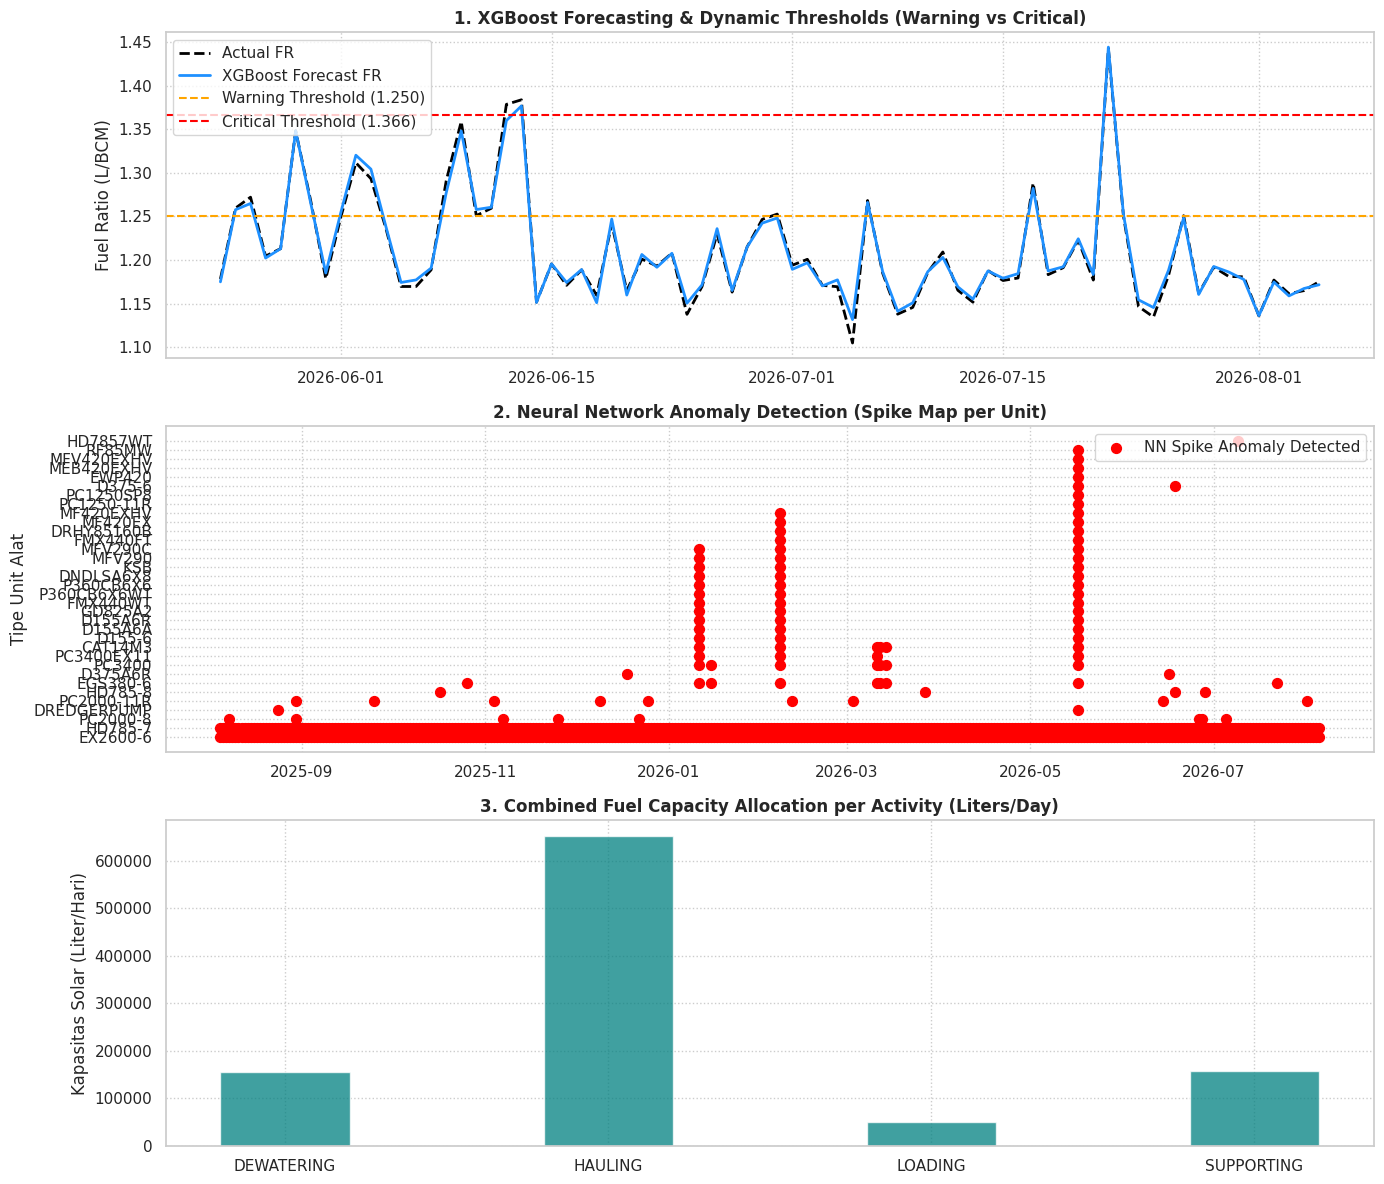

In [9]:
# ==============================================================================
# MODUL 6: VISUALISASI INTEGRASI SYSTEM DESIGN
# ==============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Chart 1: XGBoost Forecasting & Dynamic Thresholds
dates_plt = df_test_eval['Date'].values
axes[0].plot(dates_plt, df_test_eval['Actual_FR_L_BCM'], label='Actual FR', color='black', linestyle='--', linewidth=2)
axes[0].plot(dates_plt, df_test_eval['Forecast_FR_XGB'], label='XGBoost Forecast FR', color='dodgerblue', linewidth=2)
axes[0].axhline(y=WARNING_THRESHOLD, color='orange', linestyle='--', label=f'Warning Threshold ({WARNING_THRESHOLD:.3f})')
axes[0].axhline(y=CRITICAL_THRESHOLD, color='red', linestyle='--', label=f'Critical Threshold ({CRITICAL_THRESHOLD:.3f})')
axes[0].set_title('1. XGBoost Forecasting & Dynamic Thresholds (Warning vs Critical)', fontsize=12, weight='bold')
axes[0].set_ylabel('Fuel Ratio (L/BCM)')
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle=':')

# Chart 2: Neural Network Anomaly Detection Map (Spikes)
spikes = df_unit_ts[df_unit_ts['NN_Anomaly_Spike'] == 1]
axes[1].scatter(spikes['Date'], spikes['Unit'], color='red', s=50, label='NN Spike Anomaly Detected')
axes[1].set_title('2. Neural Network Anomaly Detection (Spike Map per Unit)', fontsize=12, weight='bold')
axes[1].set_ylabel('Tipe Unit Alat')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':')

# Chart 3: Combined Capacity Allocation per Activity
axes[2].bar(act_capacity_summary['Activity'], act_capacity_summary['Combined_Capacity_Fuel_Lday'], color='teal', alpha=0.75, width=0.4)
axes[2].set_title('3. Combined Fuel Capacity Allocation per Activity (Liters/Day)', fontsize=12, weight='bold')
axes[2].set_ylabel('Kapasitas Solar (Liter/Hari)')
axes[2].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

In [11]:
# ==============================================================================
# SCRIPT PARSER KAPASITAS OPERASIONAL PER JAM (CAPACITY/HOUR) PER UNIT PER ACTIVITY
# ==============================================================================

import pandas as pd
import numpy as np

def parse_mining_capacity_per_hour(file_path):
    """
    Memparsing Kapasitas Operasional Per Jam (Capacity/Hour) per unit disetiap aktivitas penambangan
    (Loading, Hauling, Supporting, Dewatering) secara presisi dari file Excel.

    Returns:
    - Pandas DataFrame berisi daftar unit, populasi, kapasitas produksi per jam (BCM/hr),
      konsumsi BBM per jam (L/hr), serta total kapasitas fleet per jam.
    """

    # 1. PARSING LOADING UNITS (Sheet Summary v1)
    df_load = pd.read_excel(file_path, sheet_name='Summary v1', skiprows=24, nrows=7)
    df_loading = pd.DataFrame({
        'Activity': 'Loading',
        'Unit_Model': df_load.iloc[:, 0].values,
        'Unit_Code': df_load.iloc[:, 2].values,
        'Qty_Units': df_load.iloc[:, 3].values,
        'Fuel_Cons_L_per_Hour': df_load.iloc[:, 4].values,
        'Prod_Capacity_BCM_per_Hour': df_load.iloc[:, 5].values
    })

    # 2. PARSING HAULING UNITS (Sheet Summary v1 - Jarak 3.900m)
    df_haul = pd.read_excel(file_path, sheet_name='Summary v1', skiprows=44, nrows=2)
    df_hauling = pd.DataFrame({
        'Activity': 'Hauling',
        'Unit_Model': df_haul.iloc[:, 0].values,
        'Unit_Code': df_haul.iloc[:, 2].values,
        'Qty_Units': df_haul.iloc[:, 3].values,
        'Fuel_Cons_L_per_Hour': df_haul.iloc[:, 4].values,
        'Prod_Capacity_BCM_per_Hour': df_haul.iloc[:, 5].values
    })

    # 3. PARSING SUPPORTING UNITS (Sheet Summary v1)
    df_supp = pd.read_excel(file_path, sheet_name='Summary v1', skiprows=24, nrows=14)
    df_supporting = pd.DataFrame({
        'Activity': 'Supporting',
        'Unit_Model': df_supp.iloc[:, 8].values,
        'Unit_Code': df_supp.iloc[:, 8].values,
        'Qty_Units': df_supp.iloc[:, 9].values,
        'Fuel_Cons_L_per_Hour': df_supp.iloc[:, 13].values,
        'Prod_Capacity_BCM_per_Hour': 0.0 # Support unit tidak memindahkan BCM langsung
    })

    # 4. PARSING DEWATERING UNITS (Sheet Summary v1)
    df_dew = pd.read_excel(file_path, sheet_name='Summary v1', skiprows=24, nrows=15)
    fc_dewatering = [40.0, 75.0, 75.0, 45.0, 10.0, 40.0, 25.0, 45.0, 45.0, 45.0, 45.0, 45.0, 45.0, 45.0, 50.0]
    df_dewatering = pd.DataFrame({
        'Activity': 'Dewatering',
        'Unit_Model': df_dew.iloc[:, 16].fillna(df_dew.iloc[:, 17]).values,
        'Unit_Code': df_dew.iloc[:, 17].values,
        'Qty_Units': df_dew.iloc[:, 18].values,
        'Fuel_Cons_L_per_Hour': fc_dewatering,
        'Prod_Capacity_BCM_per_Hour': 0.0 # Dewatering unit memindahkan debit air
    })

    # 5. GABUNGKAN SELURUH AKTIVITAS
    df_capacity_hourly = pd.concat([df_loading, df_hauling, df_supporting, df_dewatering], ignore_index=True)

    # Data Cleaning & Type Casting
    df_capacity_hourly['Qty_Units'] = pd.to_numeric(df_capacity_hourly['Qty_Units'], errors='coerce').fillna(0).astype(int)
    df_capacity_hourly['Fuel_Cons_L_per_Hour'] = pd.to_numeric(df_capacity_hourly['Fuel_Cons_L_per_Hour'], errors='coerce').fillna(0.0)
    df_capacity_hourly['Prod_Capacity_BCM_per_Hour'] = pd.to_numeric(df_capacity_hourly['Prod_Capacity_BCM_per_Hour'], errors='coerce').fillna(0.0)

    # 6. KALKULASI KAPASITAS TOTAL FLEET PER JAM
    df_capacity_hourly['Fleet_Total_Prod_BCM_per_Hour'] = df_capacity_hourly['Qty_Units'] * df_capacity_hourly['Prod_Capacity_BCM_per_Hour']
    df_capacity_hourly['Fleet_Total_Fuel_L_per_Hour'] = df_capacity_hourly['Qty_Units'] * df_capacity_hourly['Fuel_Cons_L_per_Hour']

    return df_capacity_hourly


# ==============================================================================
# EKSEKUSI PARSER DAN TAMPILKAN HASIL
# ==============================================================================
file_path = 'UPDATE_Fuel ratio calculation 2026 dummy data.xlsx'
df_hourly_capacity = parse_mining_capacity_per_hour(file_path)

# Tampilkan Ringkasan Hasil Parsing
print("=========================================================================================")
print("             HASIL PARSING KAPASITAS OPERASIONAL PER JAM PER UNIT PER AKTIVITAS           ")
print("=========================================================================================")
print(df_hourly_capacity.to_string(index=False))

# Agregasi Kapasitas Per Aktivitas
df_activity_summary = df_hourly_capacity.groupby('Activity').agg(
    Total_Populasi_Unit=('Qty_Units', 'sum'),
    Total_Kapasitas_Produksi_BCM_Jam=('Fleet_Total_Prod_BCM_per_Hour', 'sum'),
    Total_Kapasitas_BBM_Liter_Jam=('Fleet_Total_Fuel_L_per_Hour', 'sum')
).reset_index()

print("\n=========================================================================================")
print("                   RINGKASAN TOTAL KAPASITAS FLEET PER JAM PER AKTIVITAS                  ")
print("=========================================================================================")
print(df_activity_summary.to_string(index=False))

             HASIL PARSING KAPASITAS OPERASIONAL PER JAM PER UNIT PER AKTIVITAS           
  Activity                     Unit_Model     Unit_Code  Qty_Units  Fuel_Cons_L_per_Hour  Prod_Capacity_BCM_per_Hour  Fleet_Total_Prod_BCM_per_Hour  Fleet_Total_Fuel_L_per_Hour
   Loading                       EX2600-6       EX26007          3                 187.0                  920.000000                    2760.000000                        561.0
   Loading                     PC1250-11R     PC125011R         18                  59.0                  310.000000                    5580.000000                       1062.0
   Loading                      PC1250SP8     PC1250SP8         12                  64.0                  320.000000                    3840.000000                        768.0
   Loading                     PC2000-11R     PC200011R         18                 100.0                  820.000000                   14760.000000                       1800.0
   Loading              

### Analyze the impact of `NN_Spike_Events` on total fuel consumption

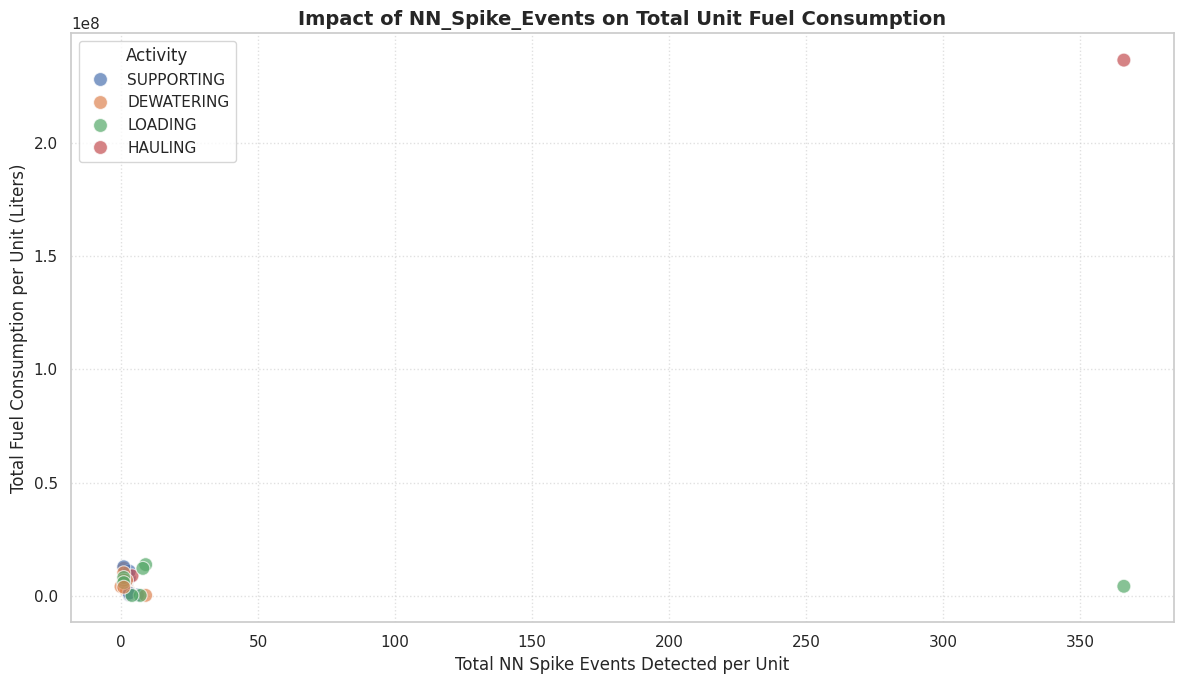


Top Units by Total NN Spike Events and their Total Fuel Consumption:
      Unit   Activity  Total_NN_Spike_Events  Total_Unit_Fuel_L_Day
   HD785-7    HAULING                    366           2.365474e+08
  EX2600-6    LOADING                    366           4.222507e+06
  EGS380-6 DEWATERING                      9           2.261591e+05
PC2000-11R    LOADING                      9           1.378110e+07
  PC2000-8    LOADING                      8           1.212600e+07
    PC3400    LOADING                      7           1.826929e+05
   CAT14M3 SUPPORTING                      6           3.643111e+05
PC3400EX11    LOADING                      4           1.617949e+05
   HD785-8    HAULING                      4           8.847649e+06
   D155A6A SUPPORTING                      3           8.949407e+05


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate df_unit_ts to get total NN_Spike_Events and total Unit_Fuel_L_Day per unit
spike_fuel_impact = df_unit_ts.groupby(['Unit', 'Activity']).agg(
    Total_NN_Spike_Events=('NN_Anomaly_Spike', 'sum'),
    Total_Unit_Fuel_L_Day=('Unit_Fuel_L_Day', 'sum')
).reset_index()

# Visualize the relationship
fig = plt.figure(figsize=(12, 7))
sns.scatterplot(data=spike_fuel_impact, x='Total_NN_Spike_Events', y='Total_Unit_Fuel_L_Day', hue='Activity', s=100, alpha=0.7)
plt.title('Impact of NN_Spike_Events on Total Unit Fuel Consumption', fontsize=14, weight='bold')
plt.xlabel('Total NN Spike Events Detected per Unit')
plt.ylabel('Total Fuel Consumption per Unit (Liters)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Activity')
plt.tight_layout()
plt.show()

# Also show the top units by Total_NN_Spike_Events and their Total_Unit_Fuel_L_Day
print("\nTop Units by Total NN Spike Events and their Total Fuel Consumption:")
print(spike_fuel_impact.sort_values(by='Total_NN_Spike_Events', ascending=False).head(10).to_string(index=False))


In [15]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "DataAnalysis"] {type:"string"}
# Assuming `fig` is the last created matplotlib figure
# upload_plt_to_gcs(num_fig, step, fig)
